In [1]:
import pandas as pd
import jieba
import matplotlib.pyplot as plt
import re
import json
# from nltk.stem import PorterStemmer
# import nltk
# from nltk.tokenize import word_tokenize
from collections import Counter
import spacy
from spacy.symbols import ORTH
from nltk.stem import PorterStemmer
import numpy as np

In [2]:
data = pd.read_csv('20250407_data jobs_處理後.csv', encoding='utf-8')

In [3]:
class term_processor:

    def __init__(self, df):

        self.nlp_en = spacy.load("en_core_web_sm") # 載入英文模型

        # 讀取英文 library
        en_dict = self.load_files("data_dict_en.txt")
        for en_word in en_dict: # 載入英文自訂 library
            self.nlp_en.tokenizer.add_special_case(en_word, [{ORTH: en_word}])

        self.nlp_ch = jieba
        jieba.load_userdict("data_dict.txt") # 引入中文字典

        self.stemmer = PorterStemmer() # 英文的 stemming
        self.stopwords = self.load_files("stopwords.txt") # 讀取中文停用詞
        self.df = df.copy()

        with open('synonym.json', 'r', encoding='utf-8') as f:
            self.synonym_dict = json.load(f) # 讀取同義字字典


    def run(self):
        temp = self.df.copy()

        # 移除標點符號符號並將英文都轉成小寫
        temp['text_normalized'] = temp['descWithoutHighlight'].str.replace(r'[^\w\u4e00-\u9fff]|_', ' ', regex=True).str.lower()
        temp['terms'] = temp['text_normalized'].apply(lambda x: self.tokenize_and_process(x))

        terms = self.get_term_df(temp) # 取得所有 terms
        terms = self.get_term_freq(temp, terms) # 取得 tfidf

        return temp, terms


    def load_files(self, file_path):
        words = []
        with open(file_path, "r", encoding="utf-8") as file:
            words = [line.strip() for line in file.readlines()]
        return words

    def detect_lang(self, text):
        hasChinese = re.search(r'[\u4e00-\u9fff]', text)
        # 只要有中文字就用中文的詞庫
        if hasChinese:
            return 'Chinese'
        else:
            return 'English'

    def tokenize_and_process(self, text):
        lang = self.detect_lang(text)

        if lang == 'Chinese':
            words = list(self.nlp_ch.cut(text))
        else:
            words = list(self.nlp_en(text))

        terms = []

        # 去除停用詞與單個字，並去除空格
        for w in words:
            word = str(w).strip()
            word = self.stemmer.stem(word) # 主要用於英文的 stemming
            word = self.synonym_dict[word] if word in self.synonym_dict.keys() else word # 中英文同義字轉換
            
            if word.isdigit(): #移除純數字
                continue
            if word not in self.stopwords and len(word) > 1:
                terms.append(word)

        return terms


    def get_term_df(self, df):

        terms_df = pd.DataFrame.from_dict(Counter(list(sum(df['terms'], []))), orient='index', columns=['count']).sort_values(by='count', ascending=False).reset_index()
        terms_df.columns = ['terms', 'count']

        terms_df = terms_df[terms_df['count'] > 2] # 排除僅出現 2 次的字

        return terms_df


    def get_term_freq(self, data, term_df):

        N = len(data['text_normalized'])
        tf = [] # 計算這個 term 在所有文本中出現的次數
        df = [] # 計算出現在幾篇職缺中

        temp = data.copy()
        temp_term_df = term_df.copy()
        terms = list(term_df['terms'])

        for term in terms:
            text = str(term)

            temp['freq'] = temp['terms'].apply(lambda x: x.count(text))
            temp['df'] = temp['freq'].apply(lambda x: 1 if x > 0 else 0)

            # group_df = temp.groupby(by='job_category').sum()[['df', 'freq']]
            # freq = list(result['terms'].apply(lambda x: x.count(text)))
            term_tf = sum(temp['freq'])
            term_df = sum(temp['df'])
            tf.append(term_tf)
            df.append(term_df)


        temp_term_df['TF'] = tf
        temp_term_df['DF'] = df
        temp_term_df['iDF'] = np.log(N/temp_term_df['DF'])
        temp_term_df['TFIDF'] = temp_term_df['TF'] * temp_term_df['iDF']
        temp_term_df['TFDF'] = temp_term_df['TF'] * temp_term_df['DF']

        return temp_term_df

In [4]:
result, terms = term_processor(data).run()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Police\AppData\Local\Temp\jieba.cache
Loading model cost 0.718 seconds.
Prefix dict has been built successfully.


In [6]:
len(result)

1954

In [7]:
terms.sort_values(by='TFDF', ascending=False).head(20)

,terms,count,TF,DF,iDF,TFIDF,TFDF
0,數據,3043,3043,1007,0.662903,2017.213646,3064301
1,開發,1687,1687,901,0.774129,1305.954906,1519987
3,分析,1535,1535,815,0.874446,1342.274179,1251025
2,ai,1549,1549,655,1.092999,1693.054827,1014595
4,技術,1206,1206,609,1.165816,1405.973571,734454
5,系統,1111,1111,540,1.286065,1428.817874,599940
7,團隊,973,973,558,1.253275,1219.436449,542934
6,模型,993,993,523,1.318052,1308.826002,519339
8,需求,890,890,533,1.299112,1156.210044,474370
9,設計,812,812,528,1.308538,1062.532490,428736


In [8]:
terms.to_excel('terms.xlsx', index=False)

## LDA 先分職位主題

In [9]:
import gensim

In [10]:
term_doc = list(result['terms'])

dictionary = gensim.corpora.Dictionary(term_doc) # 1. 將文本轉換成字典，建立詞與 ID 對應
dictionary.filter_extremes(no_below=10, no_above=0.5) # 只保留出現次數 > 10 且出現於 < 50% 文件的詞
corpus = [dictionary.doc2bow(doc) for doc in term_doc] # 2. 建立語料庫（Bag of Words）

In [13]:
# grid search
def get_best_topics(dictionary, corpus, term_doc, start, end):

    coherence_cv_values = []
    coherence_umass_values = []
    coherence_cuci_values = []
    coherence_cnpmi_values = []
    model_list = []

    for num_topics in list(range(start, end)):
        model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=50, alpha='auto', eta='auto')
        model_list.append(model)
        coherence_cv = gensim.models.CoherenceModel(model=model, texts=term_doc, dictionary=dictionary, coherence='c_v').get_coherence()
        coherence_umass = gensim.models.CoherenceModel(model=model, corpus=corpus, dictionary=dictionary, coherence='u_mass').get_coherence()
        coherence_cuci = gensim.models.CoherenceModel(model=model, texts=term_doc, dictionary=dictionary, coherence='c_uci').get_coherence()
        coherence_cnpmi = gensim.models.CoherenceModel(model=model, texts=term_doc, dictionary=dictionary, coherence='c_npmi').get_coherence()
        
        coherence_cv_values.append(coherence_cv)
        coherence_umass_values.append(coherence_umass)
        coherence_cuci_values.append(coherence_cuci)
        coherence_cnpmi_values.append(coherence_cnpmi)
        print(f'num_topics:{num_topics}, c_v: {coherence_cv:.4f}, u_mass: {coherence_umass:.4f}, c_uci: {coherence_cuci:.4f}, c_npmi: {coherence_cnpmi:.4f}')

    coherence_values = {
        "c_v": coherence_cv_values,
        "u_mass": coherence_umass_values,
        "c_uci": coherence_cuci_values,
        "c_npmi": coherence_cnpmi_values
    }
    
    return coherence_values, model_list

In [14]:
coherence_scores, models = get_best_topics(dictionary, corpus, term_doc, 4, 16)

num_topics:4, c_v: 0.3473, u_mass: -1.6897, c_uci: -0.3645, c_npmi: -0.0037
num_topics:5, c_v: 0.4351, u_mass: -1.5816, c_uci: 0.0946, c_npmi: 0.0280
num_topics:6, c_v: 0.4095, u_mass: -1.7334, c_uci: -0.1308, c_npmi: 0.0202
num_topics:7, c_v: 0.4224, u_mass: -1.6601, c_uci: 0.0992, c_npmi: 0.0316
num_topics:8, c_v: 0.4605, u_mass: -1.6628, c_uci: 0.0861, c_npmi: 0.0308
num_topics:9, c_v: 0.4392, u_mass: -1.8104, c_uci: -0.1917, c_npmi: 0.0272
num_topics:10, c_v: 0.4132, u_mass: -1.7485, c_uci: 0.0540, c_npmi: 0.0333
num_topics:11, c_v: 0.4418, u_mass: -1.6206, c_uci: 0.0538, c_npmi: 0.0307
num_topics:12, c_v: 0.4166, u_mass: -1.8511, c_uci: -0.2280, c_npmi: 0.0246
num_topics:13, c_v: 0.4586, u_mass: -1.9683, c_uci: -0.5048, c_npmi: 0.0246
num_topics:14, c_v: 0.4341, u_mass: -1.7438, c_uci: -0.1696, c_npmi: 0.0240
num_topics:15, c_v: 0.4086, u_mass: -1.9994, c_uci: -0.6743, c_npmi: 0.0029


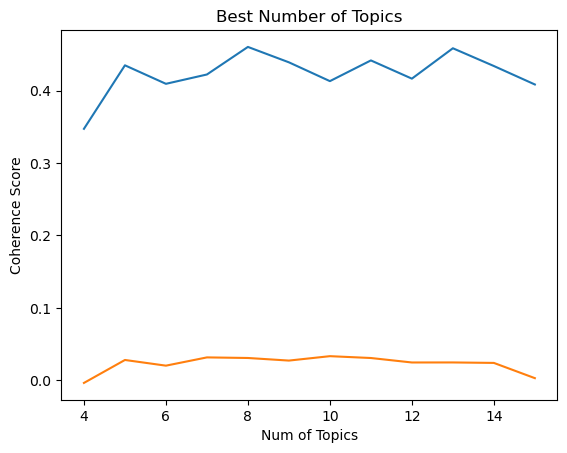

In [17]:
x = list(range(4,16))
plt.plot(x, coherence_scores["c_v"], label='c_v')
# plt.plot(x, coherence_scores["u_mass"], label='u_mass')
# plt.plot(x, coherence_scores["c_uci"], label='c_uci')
plt.plot(x, coherence_scores["c_npmi"], label='c_npmi')
plt.xlabel("Num of Topics")
plt.ylabel("Coherence Score")
plt.title('Best Number of Topics')
plt.show()

In [24]:
for idx, topic in models[6].print_topics(num_words=15):
    print(f'主題 {idx+1}\n{topic}')

主題 1
0.033*"開發" + 0.029*"處理" + 0.028*"維護" + 0.024*"SQL" + 0.023*"設計" + 0.023*"管理" + 0.022*"資料庫" + 0.021*"系統" + 0.020*"工具" + 0.019*"ETL" + 0.019*"Python" + 0.018*"平台" + 0.018*"流程" + 0.016*"商業智慧" + 0.015*"分析"
主題 2
0.089*"模型" + 0.065*"機器學習" + 0.038*"技術" + 0.034*"開發" + 0.029*"ai" + 0.024*"深度學習" + 0.023*"llm" + 0.019*"優化" + 0.017*"語言" + 0.017*"自然語言處理" + 0.017*"部署" + 0.016*"演算法" + 0.015*"設計" + 0.014*"研究" + 0.012*"Python"
主題 3
0.055*"系統" + 0.053*"需求" + 0.032*"技術" + 0.027*"專案" + 0.024*"測試" + 0.022*"設計" + 0.022*"客戶" + 0.022*"流程" + 0.020*"分析" + 0.020*"開發" + 0.018*"規劃" + 0.017*"團隊" + 0.014*"確保" + 0.013*"合作" + 0.013*"功能"
主題 4
0.044*"管理" + 0.043*"金融" + 0.035*"協助" + 0.033*"商業" + 0.021*"報表" + 0.020*"流程" + 0.019*"分析" + 0.018*"團隊" + 0.018*"成本" + 0.018*"策略" + 0.017*"銷售" + 0.017*"投資" + 0.017*"營運" + 0.016*"規劃" + 0.014*"分析師"
主題 5
0.025*"團隊" + 0.018*"開發" + 0.017*"分析" + 0.015*"工程" + 0.015*"商業" + 0.013*"成效" + 0.013*"技能" + 0.012*"實施" + 0.011*"產品" + 0.011*"解決方案" + 0.011*"確保" + 0.010*"角色" + 0.010*"流程" + 0.010*"合

In [26]:
# 儲存 model: 選擇主題數 10(c_npmi 最高)，希望主題更清晰、能直接對應實務應用
models[6].save('model_topic_10.model') 

### 對應主題

In [36]:
doc_topics = models[6].get_document_topics(corpus)

In [37]:
dominant_topics = [max(doc, key= lambda x: x[1])[0] for doc in doc_topics]

In [84]:
topics = {1: '資料工程與系統建置', 2: 'AI 模型開發與訓練', 3: '系統需求與專案管理', 4: '商業策略與金融分析', 5: '產品導入與跨部門協作', 6: 'IT 系統與文件流程管理', 7: '數位行銷與市場策略', 8: '數據洞察與決策支援', 9: 'AI 技術應用開發', 10: '智慧系統與軟體整合'}
job_title = {1: '資料工程師', 2: '機器學習工程師', 3: '系統分析師', 4: '策略顧問', 5: '資料科學家', 6: '運營流程分析師', 7: '行銷分析師', 8: '數據分析師', 9: 'AI 演算法工程師', 10: 'AI 應用開發者'}
category = {1: 'DE', 2: 'ML', 3: 'DE', 4: 'BA', 5: 'DS', 6: 'BA', 7: 'DA', 8: 'DA', 9: 'ML', 10: 'ML'}

In [85]:
result['topic_id'] = [idx+1 for idx in dominant_topics]
result['topic_name'] = [topics[idx+1] for idx in dominant_topics]
result['topic_job'] = [job_title[idx+1] for idx in dominant_topics]
result['topic_job_category'] = [category[idx+1] for idx in dominant_topics]

In [86]:
result.groupby(by=['topic_job', 'topic_name'])[['jobNo']].count()

,,jobNo
topic_job,topic_name,
AI 應用開發者,智慧系統與軟體整合,162
AI 演算法工程師,AI 技術應用開發,257
數據分析師,數據洞察與決策支援,280
機器學習工程師,AI 模型開發與訓練,226
策略顧問,商業策略與金融分析,115
系統分析師,系統需求與專案管理,188
行銷分析師,數位行銷與市場策略,183
資料工程師,資料工程與系統建置,220
資料科學家,產品導入與跨部門協作,261


In [87]:
result.to_csv('LDA topics.csv', encoding='utf-8', index=False) 